In [17]:
import math
import pypsa
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [5]:
# Adjust this to your actual file location if needed
# FILE_PATH = "20231103 - Final Supply Inputs for TYNDP 2024 Scenarios.xlsx"
FILE_PATH = Path.cwd().parent / 'data' / '20231103 - Final Supply Inputs for TYNDP 2024 Scenarios.xlsx'


def _find_sheet_name(xls: pd.ExcelFile, contents_df: pd.DataFrame, keyword: str) -> str:
    """
    Use the 'Contents' sheet to find the sheet name whose description
    contains `keyword` (e.g. 'Wind Onshore', 'Prosumer Battery').
    """
    col = contents_df["SUPPLY INPUTS "].dropna()
    for entry in col:
        entry_str = str(entry)
        if keyword.lower() in entry_str.lower():
            # First token is the sheet prefix, e.g. "1.2." from "1.2. Wind Onshore Trajectories"
            prefix = entry_str.split()[0]
            for name in xls.sheet_names:
                if name.strip().startswith(prefix):
                    return name
    raise ValueError(f"Could not find sheet for keyword {keyword!r}")


def _find_country_col_idx(df: pd.DataFrame, header_row_idx: int = 2) -> int:
    """
    Find the column index whose header (in header_row_idx) is 'Country'.
    """
    for i in range(df.shape[1]):
        val = df.iat[header_row_idx, i]
        if isinstance(val, str) and val.strip().lower() == "country":
            return i
    raise ValueError("Could not find 'Country' column")


def _find_scenario_year_col(
    df: pd.DataFrame,
    scenario_label: str,
    year: int,
    label_row_idx: int = 1,
    header_row_idx: int = 2,
) -> int:
    """
    Given a scenario label as it appears in row `label_row_idx` (e.g. 'LOW',
    'Best Estimate', 'BEST ESTIMATE (BE)', 'Distributed Energy', etc.),
    find which column corresponds to the given `year` within that scenario block.
    """
    scenario_label_low = scenario_label.lower()
    start_idx = None

    # 1) Find the first column where the label row contains the scenario label
    for i in range(df.shape[1]):
        cell = df.iat[label_row_idx, i]
        if isinstance(cell, str) and scenario_label_low in cell.lower():
            start_idx = i
            break

    if start_idx is None:
        raise ValueError(f"Scenario label {scenario_label!r} not found in row {label_row_idx}")

    # 2) Find where this scenario block ends (next non-empty label cell)
    end_idx = df.shape[1]
    for j in range(start_idx + 1, df.shape[1]):
        cell = df.iat[label_row_idx, j]
        if isinstance(cell, str) and cell.strip() != "":
            end_idx = j
            break

    # 3) Within the scenario block, find the column whose header row has the requested year
    for j in range(start_idx, end_idx):
        v = df.iat[header_row_idx, j]
        if isinstance(v, (int, float)) and not math.isnan(v) and int(v) == int(year):
            return j

    raise ValueError(f"Year {year} not found for scenario {scenario_label!r}")


def _extract_from_sheet(
    xls: pd.ExcelFile,
    sheet_name: str,
    year: int,
    scenario_labels: dict,
) -> dict:
    """
    Core extractor for a 'trajectory' sheet.

    scenario_labels: mapping like
        {"LOW": "LOW", "BE": "Best Estimate", "HIGH": "HIGH"}
    or for nuclear:
        {"LOW": "Distributed Energy", "BE": "National Trends+", "HIGH": "Global Ambition"}
    """
    df = pd.read_excel(xls, sheet_name=sheet_name)

    label_row_idx = 1   # row with scenario names (LOW, BE, HIGH, etc.)
    header_row_idx = 2  # row with 'Country' and years

    country_col_idx = _find_country_col_idx(df, header_row_idx=header_row_idx)

    # Map each of LOW / BE / HIGH to the correct column index for this year
    col_map = {}
    for key, label in scenario_labels.items():
        col_map[key] = _find_scenario_year_col(
            df,
            scenario_label=label,
            year=year,
            label_row_idx=label_row_idx,
            header_row_idx=header_row_idx,
        )

    out = {}
    # Data rows start after the header rows
    for r in range(header_row_idx + 1, df.shape[0]):
        country = df.iat[r, country_col_idx]
        if not isinstance(country, str) or not country.strip():
            continue
        country = country.strip()

        # Keep only 4-character country codes (AL00, DE00, UKNI, etc.)
        if len(country) != 4:
            continue

        vals = {}
        for key, col_idx in col_map.items():
            val = df.iat[r, col_idx]
            if isinstance(val, float) and math.isnan(val):
                val = None
            elif isinstance(val, (int, float)):
                val = float(val)
            vals[key] = val

        out[country] = vals

    return out


def extract_supply_inputs(year: int, carrier: str, path: str = FILE_PATH) -> dict:
    """
    Extract LOW, BE (best estimate), and HIGH trajectories for a given carrier and year.

    Parameters
    ----------
    year : int
        2030 or 2040.
    carrier : str
        One of: 'onwind', 'offwind', 'solar', 'battery', 'nuclear'.
    path : str
        Path to the Excel workbook
        "20231103 - Final Supply Inputs for TYNDP 2024 Scenarios.xlsx".

    Returns
    -------
    dict
        {country_code: {"LOW": float or None, "BE": float or None, "HIGH": float or None}}
    """
    year = int(year)
    if year not in (2030, 2040):
        raise ValueError("year must be 2030 or 2040")

    carrier = carrier.lower()

    with pd.ExcelFile(path) as xls:
        contents_df = pd.read_excel(xls, sheet_name="Contents")

        if carrier == "solar":
            sheet = _find_sheet_name(xls, contents_df, "Solar Trajectories")
            scenario_labels = {"LOW": "LOW", "BE": "Best Estimate", "HIGH": "HIGH"}
            return _extract_from_sheet(xls, sheet, year, scenario_labels)

        elif carrier == "onwind":
            sheet = _find_sheet_name(xls, contents_df, "Wind Onshore")
            # In the sheet this appears as "BEST ESTIMATE (BE)"
            scenario_labels = {"LOW": "LOW", "BE": "BEST ESTIMATE", "HIGH": "HIGH"}
            return _extract_from_sheet(xls, sheet, year, scenario_labels)

        elif carrier == "offwind":
            sheet = _find_sheet_name(xls, contents_df, "Wind Offshore")
            scenario_labels = {"LOW": "LOW", "BE": "BEST ESTIMATE", "HIGH": "HIGH"}
            return _extract_from_sheet(xls, sheet, year, scenario_labels)

        elif carrier == "nuclear":
            sheet = _find_sheet_name(xls, contents_df, "Nuclear Ex-ante capacities")
            # Interpret TYNDP scenarios as LOW / BE / HIGH:
            #   Distributed Energy   -> LOW
            #   National Trends+     -> BE (Best Estimate)
            #   Global Ambition      -> HIGH
            scenario_labels = {
                "LOW": "Distributed Energy",
                "BE": "National Trends+",
                "HIGH": "Global Ambition",
            }
            return _extract_from_sheet(xls, sheet, year, scenario_labels)

        elif carrier == "battery":
            # Combine Prosumer + Utility battery capacities (both in MWh)
            prosumer_sheet = _find_sheet_name(xls, contents_df, "Prosumer Battery")
            utility_sheet = _find_sheet_name(xls, contents_df, "Utility Battery")

            scenario_labels = {"LOW": "LOW", "BE": "Best Estimate", "HIGH": "HIGH"}

            prosumer = _extract_from_sheet(xls, prosumer_sheet, year, scenario_labels)
            utility = _extract_from_sheet(xls, utility_sheet, year, scenario_labels)

            result = {}
            countries = set(prosumer) | set(utility)
            for c in countries:
                result[c] = {}
                for key in ("LOW", "BE", "HIGH"):
                    v1 = prosumer.get(c, {}).get(key)
                    v2 = utility.get(c, {}).get(key)

                    if v1 is None and v2 is None:
                        total = None
                    elif v1 is None:
                        total = v2
                    elif v2 is None:
                        total = v1
                    else:
                        total = v1 + v2

                    result[c][key] = total
            return result

        else:
            raise ValueError("carrier must be one of: 'onwind', 'offwind', 'solar', 'battery', 'nuclear'")


In [ ]:
data = extract_supply_inputs(2030, "onwind")
print(data)

{'AL00': {'LOW': 280.0, 'BE': 280.0, 'HIGH': 280.0}, 'AT00': {'LOW': 7500.000834298155, 'BE': 9000.001001157783, 'HIGH': 11096.0}, 'BA00': {'LOW': 786.6, 'BE': 786.6, 'HIGH': 786.6}, 'BE00': {'LOW': 4900.0, 'BE': 5248.0, 'HIGH': 5300.0}, 'BG00': {'LOW': 800.0, 'BE': 948.0, 'HIGH': 1896.0}, 'CH00': {'LOW': 180.0, 'BE': 310.0, 'HIGH': 310.0}, 'CY00': {'LOW': 157.5, 'BE': 197.5, 'HIGH': 200.0}, 'CZ00': {'LOW': 741.0, 'BE': 958.3, 'HIGH': 1665.0}, 'DE00': {'LOW': 115000.0, 'BE': 115000.7, 'HIGH': 115000.0}, 'DEKF': {'LOW': 0.0, 'BE': 0.0, 'HIGH': 0.0}, 'DKE1': {'LOW': 500.0, 'BE': 1155.3842000000002, 'HIGH': 1995.4137147075724}, 'DKKF': {'LOW': 0.0, 'BE': 0.0, 'HIGH': 0.0}, 'DKW1': {'LOW': 3500.0, 'BE': 6150.2278, 'HIGH': 10504.586285292426}, 'EE00': {'LOW': 634.0, 'BE': 861.0, 'HIGH': 1200.0}, 'ES00': {'LOW': 45400.0, 'BE': 48317.493999999984, 'HIGH': 57200.0}, 'FI00': {'LOW': 13000.0, 'BE': 25992.471153341343, 'HIGH': 26000.0}, 'FR00': {'LOW': 28000.0, 'BE': 31299.99967555258, 'HIGH': 39

In [49]:
def to_dataframe(data):
    df = pd.DataFrame(data).T
    for col in df.columns:
        df[col] = df[col].apply(lambda x: str(x).replace('\xa0', '').replace(',', '').strip() if pd.notna(x) else x)
    df = df.astype(float).groupby(df.index.str[:2]).sum()
    df = df.rename({'UK': 'GB'}).sort_index()
    return df.rename(columns={'BE': 'NT'})

In [52]:
carriers = ['onwind', 'offwind', 'solar', 'battery', 'nuclear']
tyndp_capacities = pd.concat([to_dataframe(extract_supply_inputs(2030, c)) for c in carriers], axis=1, keys=carriers)
tyndp_capacities

onwind                                  offwind               \
              LOW             NT         HIGH          LOW           NT   
AL     280.000000     280.000000     280.0000      0.00000      0.00000   
AT    7500.000834    9000.001001   11096.0000      0.00000      0.00000   
BA     786.600000     786.600000     786.6000      0.00000      0.00000   
BE    4900.000000    5248.000000    5300.0000   5760.00000   5760.00000   
BG     800.000000     948.000000    1896.0000      0.00000      0.00000   
CH     180.000000     310.000000     310.0000      0.00000      0.00000   
CY     157.500000     197.500000     200.0000      0.00000      0.00000   
CZ     741.000000     958.300000    1665.0000      0.00000      0.00000   
DE  115000.000000  115000.700000  115000.0000  30521.30000  30521.30000   
DK    4000.000000    7305.612000   12500.0000   8250.60000   8250.60000   
EE     634.000000     861.000000    1200.0000      0.00000      0.00000   
ES   45400.000000   48317.494000   57200.0000   2800.00000   2800.00000   
FI   13000.000000   25992.471153   26000.0000   1000.00000   1000.00000   
FR   28000.000000   31299.999676   39000.0000   3875.00000   3875.00000   
GB   24736.589700   32199.175209   41503.5684  52467.46998  52467.46998   
GR    7088.811071    7100.000000   12500.0000   2700.00000   2700.00000   
HR    1500.000000    1441.950000    1800.0000    510.00000    510.00000   
HU     334.290000     334.290000    1080.0000      0.00000      0.00000   
IE    7000.000000    8952.800000    8975.0000   5025.20000   5025.20000   
IT   16571.000000   18410.819770   19332.0000   8500.00000   8500.00000   
LT    5000.000000    5000.020000    5000.0000   1400.00000   1400.00000   
LU       0.000000     400.000000     400.0000      0.00000      0.00000   
LV     237.000000     237.000000     450.0000    500.00000    500.00000   
ME       0.000000     254.200000     254.2000      0.00000      0.00000   
MK     180.000000     410.000000    1100.0000      0.00000      0.00000   
MT       0.000000       0.000000       0.0000      0.00000      0.00000   
NL    7500.000000    9100.049570   10300.0000  16542.50000  16542.50000   
NO    5307.390000    5773.225000    5793.3650   3003.50000   3003.50000   
PL   10806.000000   13767.840000   19000.0000  10004.00000  10004.00000   
PT    8699.500000    8699.500000   10000.0000   2000.00000   2000.00000   
RO    5255.000000    6000.000000    6500.0000   1000.00000   1000.00000   
RS    4282.250000    4812.150000    4812.1500      0.00000      0.00000   
SE   15798.223271   17952.152439   21600.0000    600.00000    600.00000   
SI      60.000000     122.443455     151.0000      0.00000      0.00000   
SK     715.000000     715.000000     715.0000      0.00000      0.00000   

                           solar                                 battery  \
             HIGH            LOW             NT           HIGH       LOW   
AL       0.000000     600.000000     600.000000     600.000000      0.00   
AT       0.000000   12000.000000   12000.257000   30000.000000    101.60   
BA       0.000000     454.800000     454.800000     454.800000      0.00   
BE    5760.000000   11000.000000   13610.000000   15000.000000   1625.00   
BG       0.000000    2500.000000    3458.237000    6915.000000   6000.00   
CH       0.000000    7650.000000    9770.268571   12210.000000    610.60   
CY       0.000000     804.000000     852.000000    1070.000000      0.00   
CZ       0.000000   10820.000000   11405.700000   15218.000000    842.00   
DE   30521.300000  215000.000000  215002.000000  215000.000000  56938.80   
DK  119161.600000    4924.000000   17744.410000   62271.402214   2000.00   
EE    1000.000000    1000.000000    1160.000000    1500.000000      0.00   
ES    3400.000000   42937.500000   64848.127000   96050.000000   6400.00   
FI    7000.000000    3000.000000   10695.187166   20000.000000   2000.00   
FR    4542.422166   23000.000000   42282.190000   58000.000000    940.00   
GB   53251.340000  

In [ ]:
bat_2040 = extract_supply_inputs(2040, "battery")
print(bat_2040["DE00"])

In [18]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__24H-T-H-B-I-A-dist1_2025.nc'
)

INFO:pypsa.io:Imported network base_s_50__24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


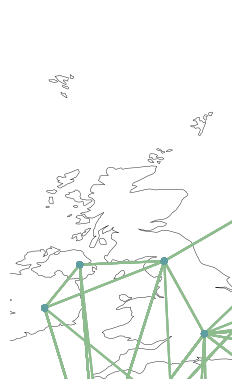

In [26]:
import cartopy.crs as ccrs

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
n.plot(ax=ax)
ax.set_xlim(-9, 0)
ax.set_ylim(50, 65)
plt.show()

In [27]:
n.buses.location.unique()

array(['AL0 0', 'AT0 0', 'BA0 0', 'BE0 0', 'BG0 0', 'CH0 0', 'CZ0 0',
       'DE0 0', 'DE0 1', 'DE0 2', 'DE0 3', 'DE0 4', 'DE0 5', 'DK0 0',
       'DK1 0', 'EE0 0', 'ES0 0', 'ES6 0', 'FI1 0', 'FR0 0', 'FR0 1',
       'FR0 2', 'FR0 3', 'FR0 4', 'FR5 0', 'GB2 0', 'GB2 1', 'GB3 0',
       'GR0 0', 'HR0 0', 'HU0 0', 'IE3 0', 'IT0 0', 'IT0 1', 'IT4 0',
       'LT0 0', 'LU0 0', 'LV0 0', 'ME0 0', 'MK0 0', 'NL0 0', 'NO1 0',
       'PL0 0', 'PT0 0', 'RO0 0', 'RS0 0', 'SE1 0', 'SI0 0', 'SK0 0',
       'XK0 0', 'EU', ''], dtype=object)